## **Скачивание библиотеки wfdb для чтения медицинских показаний**

In [1]:
!pip install wfdb


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


## **Импортирование нужных библиотек**

In [52]:
import wfdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn
import scipy
import ast

## **Скачивание базы данных**

In [3]:
# !wget -r -N -c -np "https://physionet.org/files/ptb-xl/1.0.3/records100/"

In [4]:
# !wget -r -N -c -np https://physionet.org/files/ptb-xl-plus/1.0.1/features/12sl_features.csv
# !wget -r -N -c -np https://physionet.org/files/ptb-xl-plus/1.0.1/features/feature_description.csv
# !wget -r -N -c -np https://physionet.org/files/ptb-xl-plus/1.0.1/labels/

## **Извлечение данных из баз данных**

In [8]:
ptb_xl = pd.read_csv("data/raw/ptb-xl/ptbxl_database.csv")
ptb_xlp = pd.read_csv("data/raw/ptb-xl+/features/12sl_features.csv")
scp_stat = pd.read_csv("data/raw/ptb-xl/scp_statements.csv")


# **Составление и очистка базы данных**

### Составление своей базы данных через merge двух нужных баз

In [10]:
selected_columns = ptb_xl[
    [
        "ecg_id",
        "patient_id",
        "age",
        "sex",
        "strat_fold",
        "filename_lr",
        "scp_codes"
    ]
]
selected_columns.to_csv("data/processed/ecg_research_dataset.csv", index=False)

In [23]:
selected_columns2 = ptb_xlp[
    [
    "ecg_id",
    "HR_Ventr_Global",
    "RR_Mean_Global",
    "QRS_Count_Global",
    "PR_Int_Global",
    "QRS_Dur_Global",
    "QT_Int_Global",
    "QT_IntCorr_Global",
    "QT_IntBazett_Global",
    "QT_IntFridericia_Global",
    "QT_IntFramingham_Global",
    "P_AxisFront_Global",
    "R_AxisFrontal_Global",
    "T_AxisFront_Global",
    "P_Dur_Global",
    "P_Found_Global"
]]
selected_columns2 = selected_columns2.rename(columns={
    "HR_Ventr_Global": "heart_rate",
    "RR_Mean_Global": "rr_mean",
    "QRS_Count_Global": "qrs_count",
    "PR_Int_Global": "pr_interval",
    "QRS_Dur_Global": "qrs_duration",
    "QT_Int_Global": "qt_interval",
    "QT_IntCorr_Global": "qtc_corrected",
    "QT_IntBazett_Global": "qtc_bazett",
    "QT_IntFridericia_Global": "qtc_fridericia",
    "QT_IntFramingham_Global": "qtc_framingham",
    "P_AxisFront_Global": "p_axis",
    "R_AxisFrontal_Global": "qrs_axis",
    "T_AxisFront_Global": "t_axis",
    "P_Dur_Global": "p_duration",
    "P_Found_Global": "p_found"
})

main = pd.read_csv("data/processed/ecg_research_dataset.csv")
merge = main.merge(selected_columns2, on="ecg_id", how="right")
merge.to_csv("data/processed/ecg_research_dataset.csv", index=False)

In [ ]:
data = pd.read_csv("data/processed/ecg_research_dataset.csv")
data = data.drop(columns=["sex_y", "patient_id_y","age_y","sex_y","strat_fold_y","filename_lr_y","scp_codes_y"])
rename_columns = {i : i[:-2] for i in data.columns if i[-1] == "x" and i[-2] == "_"}
data = data.rename(columns=rename_columns)
data.to_csv("data/processed/ecg_research_dataset.csv", index=False)


KeyError: "['sex_y', 'patient_id_y', 'age_y', 'sex_y', 'strat_fold_y', 'filename_lr_y', 'scp_codes_y'] not found in axis"

In [40]:
data = pd.read_csv("data/processed/ecg_research_dataset.csv")
data = data.drop(columns=data.columns[:2])
data.to_csv("data/processed/ecg_research_dataset.csv", index=False)

In [44]:
codes = data["scp_codes"].apply(ast.literal_eval)
scp_data = pd.json_normalize(codes).fillna(0)
scp_data = scp_data.add_prefix("scp_")
data = pd.concat([data, scp_data], axis=1)
def abnormal(x):
    active = [k for k, v in x.items() if v > 0]
    return 0 if active == ["NORM"] else 1
data['abnormal_flag'] = codes.apply(abnormal)
data.to_csv("data/processed/ecg_research_dataset.csv", index=False)

In [ ]:
data["num_diagnoses"] = codes.apply(lambda x: sum(1 for v in x.values() if v > 0))
def ages(x):
    if x < 35: return "young"
    if x < 60: return "middle"
    return "senior"
data["age_group"] = data["age"].apply(ages)

,ecg_id,patient_id,age,sex,strat_fold,filename_lr,scp_codes,heart_rate,rr_mean,qrs_count,...,scp_INJIL,scp_2AVB,scp_PRC(S),scp_PSVT,scp_PMI,scp_STE_,scp_WPW,scp_INJIN,num_diagnoses,age_group
0,1,15709.0,56.0,1,3,records100/00000/00001_lr,"{'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}",64.0,938.0,11.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,middle
1,21803,12842.0,87.0,1,2,records100/21000/21803_lr,"{'CRBBB': 100.0, 'SARRH': 0.0}",75.0,802.0,12.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,senior
2,21804,12842.0,87.0,1,2,records100/21000/21804_lr,"{'CRBBB': 100.0, 'AFIB': 0.0}",169.0,354.0,27.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,senior
3,21805,16291.0,72.0,0,3,records100/21000/21805_lr,"{'ASMI': 100.0, 'ISCAL': 100.0, 'LAFB': 100.0,...",79.0,756.0,13.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4,senior
4,21806,20136.0,85.0,0,5,records100/21000/21806_lr,"{'NDT': 100.0, 'SR': 0.0}",92.0,650.0,15.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,senior
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21794,21834,20703.0,300.0,0,4,records100/21000/21834_lr,"{'NORM': 100.0, 'ABQRS': 0.0, 'SR': 0.0}",67.0,894.0,11.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,senior
21795,21835,19311.0,59.0,1,2,records100/21000/21835_lr,"{'ISCAS': 50.0, 'SR': 0.0}",59.0,1022.0,9.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,middle
21796,21836,8873.0,64.0,1,8,records100/21000/21836_lr,"{'NORM': 100.0, 'SR': 0.0}",70.0,858.0,12.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,senior
21797,21837,11744.0,68.0,0,9,records100/21000/21837_lr,"{'NORM': 100.0, 'SR': 0.0}",59.0,1012.0,10.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,senior


### Нужно понять, как определить heart_rate_group. Для этого сначала построим визуализацию и разнесем в 3 группы: bradycardia, normal_hr, tachycardia

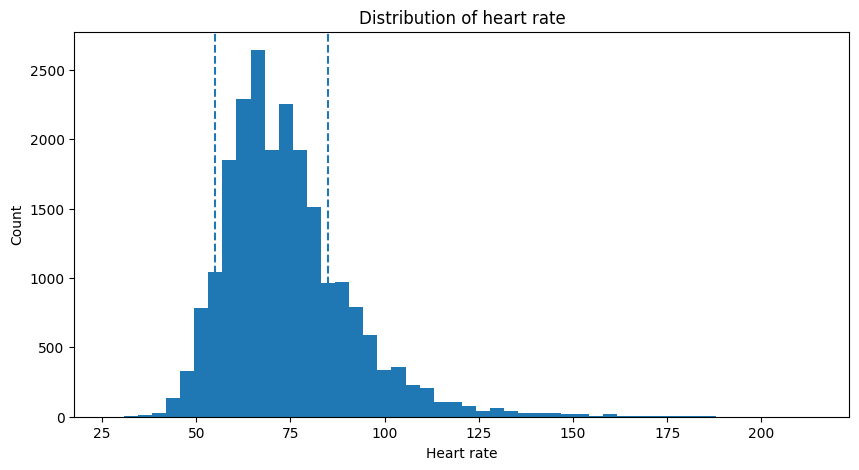

In [57]:
plt.figure(figsize=(10, 5))
plt.hist(data["heart_rate"].dropna(), bins=50)
plt.xlabel("Heart rate")
plt.ylabel("Count")
plt.title("Distribution of heart rate")
plt.axvline(55, linestyle="--", label="HR = 60")
plt.axvline(85, linestyle="--", label="HR = 100")
plt.show()

In [58]:
def hrg(x):
    if x < 55: return "bradycardia"
    if x < 85: return "normal_hr"
    return "tachycardia"
data["heart_rate_group"] = data["heart_rate"].apply(hrg)
data

,ecg_id,patient_id,age,sex,strat_fold,filename_lr,scp_codes,heart_rate,rr_mean,qrs_count,...,scp_2AVB,scp_PRC(S),scp_PSVT,scp_PMI,scp_STE_,scp_WPW,scp_INJIN,num_diagnoses,age_group,heart_rate_group
0,1,15709.0,56.0,1,3,records100/00000/00001_lr,"{'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}",64.0,938.0,11.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,middle,normal_hr
1,21803,12842.0,87.0,1,2,records100/21000/21803_lr,"{'CRBBB': 100.0, 'SARRH': 0.0}",75.0,802.0,12.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,senior,normal_hr
2,21804,12842.0,87.0,1,2,records100/21000/21804_lr,"{'CRBBB': 100.0, 'AFIB': 0.0}",169.0,354.0,27.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,senior,tachycardia
3,21805,16291.0,72.0,0,3,records100/21000/21805_lr,"{'ASMI': 100.0, 'ISCAL': 100.0, 'LAFB': 100.0,...",79.0,756.0,13.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4,senior,normal_hr
4,21806,20136.0,85.0,0,5,records100/21000/21806_lr,"{'NDT': 100.0, 'SR': 0.0}",92.0,650.0,15.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,senior,tachycardia
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21794,21834,20703.0,300.0,0,4,records100/21000/21834_lr,"{'NORM': 100.0, 'ABQRS': 0.0, 'SR': 0.0}",67.0,894.0,11.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,senior,normal_hr
21795,21835,19311.0,59.0,1,2,records100/21000/21835_lr,"{'ISCAS': 50.0, 'SR': 0.0}",59.0,1022.0,9.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,middle,normal_hr
21796,21836,8873.0,64.0,1,8,records100/21000/21836_lr,"{'NORM': 100.0, 'SR': 0.0}",70.0,858.0,12.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,senior,normal_hr
21797,21837,11744.0,68.0,0,9,records100/21000/21837_lr,"{'NORM': 100.0, 'SR': 0.0}",59.0,1012.0,10.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,senior,normal_hr


2


### Data cleanup preparation

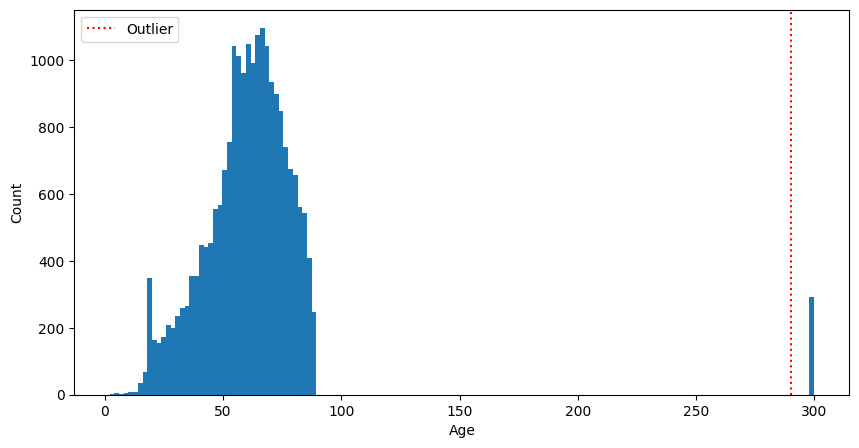

In [86]:
plt.figure(figsize=(10,5))
plt.hist(data["age"].dropna(), bins = 150)
plt.xlabel("Age")
plt.ylabel("Count")
plt.axvline(290, color="red", label="Outlier", linestyle=":")
plt.legend()
plt.show()

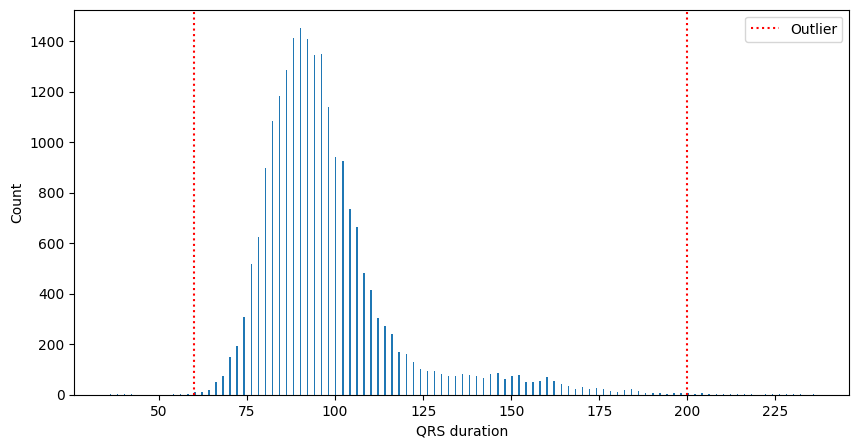

In [92]:
plt.figure(figsize=(10, 5))
plt.hist(data["qrs_duration"].dropna(), bins = 500)
plt.xlabel("QRS duration")
plt.ylabel("Count")
plt.axvline(200, linestyle=":", color = "red", label="Outlier")
plt.axvline(60, linestyle=":", color = "red")
plt.legend()
plt.show()

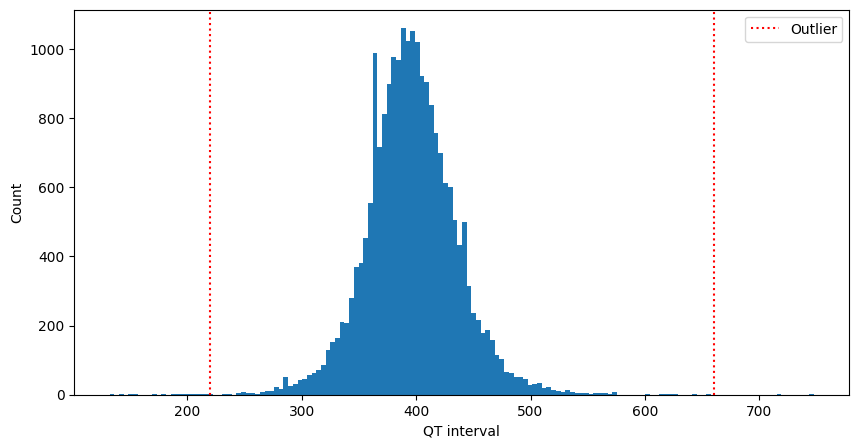

In [95]:
plt.figure(figsize=(10, 5))
plt.hist(data["qt_interval"].dropna(), bins = 150)
plt.xlabel("QT interval")
plt.ylabel("Count")
plt.axvline(220, label="Outlier", linestyle=":", color="red")
plt.axvline(660, linestyle=":", color="red")
plt.legend()
plt.show()

In [102]:
for col in data.columns:
    sm = data[col].isna().sum()
    if sm > 0:
        print(f"{col}: {sm}")

pr_interval: 2013
p_axis: 1994
qrs_axis: 1
t_axis: 4
p_duration: 2032


### Data cleanup

In [115]:
cdata = data[data["age"] < 200]
cdata = cdata[cdata["qrs_duration"] > 60]
cdata = cdata[cdata["qrs_duration"] < 200]
cdata = cdata[cdata["qt_interval"] > 220]
cdata = cdata[cdata["qt_interval"] < 660]
cdata

,ecg_id,patient_id,age,sex,strat_fold,filename_lr,scp_codes,heart_rate,rr_mean,qrs_count,...,scp_PRC(S),scp_PSVT,scp_PMI,scp_STE_,scp_WPW,scp_INJIN,num_diagnoses,age_group,heart_rate_group,pr_missing
0,1,15709.0,56.0,1,3,records100/00000/00001_lr,"{'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}",64.0,938.0,11.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1,middle,normal_hr,0
1,21803,12842.0,87.0,1,2,records100/21000/21803_lr,"{'CRBBB': 100.0, 'SARRH': 0.0}",75.0,802.0,12.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1,senior,normal_hr,0
2,21804,12842.0,87.0,1,2,records100/21000/21804_lr,"{'CRBBB': 100.0, 'AFIB': 0.0}",169.0,354.0,27.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1,senior,tachycardia,1
3,21805,16291.0,72.0,0,3,records100/21000/21805_lr,"{'ASMI': 100.0, 'ISCAL': 100.0, 'LAFB': 100.0,...",79.0,756.0,13.0,...,0.0,0.0,0.0,0.0,0.0,0.0,4,senior,normal_hr,0
4,21806,20136.0,85.0,0,5,records100/21000/21806_lr,"{'NDT': 100.0, 'SR': 0.0}",92.0,650.0,15.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1,senior,tachycardia,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21793,21833,17180.0,67.0,1,7,records100/21000/21833_lr,"{'NDT': 100.0, 'PVC': 100.0, 'VCLVH': 0.0, 'ST...",108.0,556.0,18.0,...,0.0,0.0,0.0,0.0,0.0,0.0,2,senior,tachycardia,0
21795,21835,19311.0,59.0,1,2,records100/21000/21835_lr,"{'ISCAS': 50.0, 'SR': 0.0}",59.0,1022.0,9.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1,middle,normal_hr,0
21796,21836,8873.0,64.0,1,8,records100/21000/21836_lr,"{'NORM': 100.0, 'SR': 0.0}",70.0,858.0,12.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1,senior,normal_hr,0
21797,21837,11744.0,68.0,0,9,records100/21000/21837_lr,"{'NORM': 100.0, 'SR': 0.0}",59.0,1012.0,10.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1,senior,normal_hr,0


In [116]:
cdata = cdata.dropna(subset=["qrs_axis"])
cdata = cdata.dropna(subset=["t_axis"])
cdata['pr_missing'] = cdata['pr_interval'].isna().astype(int)
cdata["pr_interval"] = cdata["pr_interval"].fillna(0)


In [117]:
no_p = cdata['p_found'] == 0
no_pr = cdata['pr_interval'] == 0
print("Нет P-волны:", no_p.sum())
print("Нет PR:", no_pr.sum())  
print("Совпадают:", (no_p & no_pr).sum())

Нет P-волны: 1924
Нет PR: 1880
Совпадают: 1752


In [123]:
cdata[cdata["scp_AFIB"] > 0]

,ecg_id,patient_id,age,sex,strat_fold,filename_lr,scp_codes,heart_rate,rr_mean,qrs_count,...,scp_PRC(S),scp_PSVT,scp_PMI,scp_STE_,scp_WPW,scp_INJIN,num_diagnoses,age_group,heart_rate_group,pr_missing
4112,4117,19574.0,39.0,0,9,records100/04000/04117_lr,{'AFIB': 100.0},131.0,456.0,21.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1,middle,tachycardia,1
4396,4401,12743.0,71.0,1,4,records100/04000/04401_lr,{'AFIB': 100.0},136.0,442.0,22.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1,senior,tachycardia,1
4418,4423,12743.0,71.0,1,4,records100/04000/04423_lr,{'AFIB': 100.0},131.0,456.0,22.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1,senior,tachycardia,1
4526,4531,12743.0,71.0,1,4,records100/04000/04531_lr,{'AFIB': 100.0},87.0,686.0,14.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1,senior,tachycardia,1
4527,4532,12743.0,71.0,1,4,records100/04000/04532_lr,{'AFIB': 100.0},85.0,704.0,14.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1,senior,tachycardia,1
4756,4761,9303.0,61.0,1,9,records100/04000/04761_lr,"{'NST_': 100.0, 'AFIB': 100.0}",105.0,568.0,18.0,...,0.0,0.0,0.0,0.0,0.0,0.0,2,senior,tachycardia,1
5629,5634,19290.0,73.0,0,8,records100/05000/05634_lr,{'AFIB': 100.0},67.0,900.0,11.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1,senior,normal_hr,1
5771,5776,14650.0,67.0,0,8,records100/05000/05776_lr,{'AFIB': 100.0},85.0,706.0,14.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1,senior,tachycardia,1
7209,7215,19304.0,74.0,1,7,records100/07000/07215_lr,{'AFIB': 100.0},68.0,878.0,11.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1,senior,normal_hr,1
7483,7489,16814.0,74.0,0,8,records100/07000/07489_lr,"{'LMI': 100.0, 'IPMI': 100.0, 'PVC': 100.0, 'A...",132.0,454.0,22.0,...,0.0,0.0,0.0,0.0,0.0,0.0,4,senior,tachycardia,1
